In [34]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

from tensorflow.keras.models import Sequential

from tensorflow.keras.layers import (
    Embedding,
    LSTM,
    Dense,
    Dropout
)

from tensorflow.keras.callbacks import EarlyStopping

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

import matplotlib.pyplot as plt
import seaborn as sns

In [35]:
df = pd.read_csv("../data/processed_reviews.csv")

df.head()

,Reviewer Name,Profile Link,Country,Review Count,Review Date,Rating,Review Title,Review Text,Date of Experience,Sentiment,Clean_Review,Sentiment_Label
0,Lisa,/users/63c2d28aff751c001470ce46,US,1 review,2023-01-14T18:41:59.000Z,1,What happened to quality customer service?,"I ordered several items on Jan 2, this review ...","January 14, 2023",Negative,ordered several item jan review reference retu...,0
1,J Ellery,/users/4f5291a30000640001153f96,GB,6 reviews,2012-03-03T21:50:56.000Z,5,Best on the web,Never any problems.goods always arrive when st...,"March 03, 2012",Positive,never problemsgoods always arrive stated exell...,2
2,Heather Weber,/users/5d37078e6614abe3ab453adf,US,1 review,2019-07-23T13:12:41.000Z,3,Issues with online purchases,"Recently, I have been having issues with my or...","July 23, 2019",Neutral,recently issue order receiving item not order ...,1
3,Mrs Lowe,/users/5666ab6d0000ff0001f14958,GB,2 reviews,2015-12-08T10:07:54.695Z,5,Excellent as always,Very good.,NaN,Positive,good,2
4,Lolo Paz,/users/5d8732fb681610d90db66d2e,US,2 reviews,2019-09-22T08:41:50.000Z,4,Ive been shopping with amazon for…,Ive been shopping with amazon for almost a yea...,"September 22, 2019",Positive,shopping amazon almost year get delivery avera...,2


In [36]:
df.info()

df.isnull().sum()

df["Sentiment"].value_counts()

<class 'pandas.DataFrame'>
RangeIndex: 42739 entries, 0 to 42738
Data columns (total 12 columns):
 #   Column              Non-Null Count  Dtype
---  ------              --------------  -----
 0   Reviewer Name       42739 non-null  str  
 1   Profile Link        42739 non-null  str  
 2   Country             42736 non-null  str  
 3   Review Count        42739 non-null  str  
 4   Review Date         42739 non-null  str  
 5   Rating              42739 non-null  int64
 6   Review Title        42739 non-null  str  
 7   Review Text         42739 non-null  str  
 8   Date of Experience  41636 non-null  str  
 9   Sentiment           42739 non-null  str  
 10  Clean_Review        42739 non-null  str  
 11  Sentiment_Label     42739 non-null  int64
dtypes: int64(2), str(10)
memory usage: 3.9 MB


Sentiment
Positive    17923
Negative    14348
Neutral     10468
Name: count, dtype: int64

fit() learns the unique class names.

transform() converts those names into integers.

fit_transform() performs both steps in one call.



In [37]:
from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()

df["label"] = encoder.fit_transform(df["Sentiment"])

print(encoder.classes_)

['Negative' 'Neutral' 'Positive']


In [38]:
X = df['Clean_Review']

y = df['Sentiment_Label']

In [ ]:
from tensorflow.keras.preprocessing.text import Tokenizer

MAX_WORDS = 10000  ## 10k most common words

tokenizer = Tokenizer(
    num_words=MAX_WORDS,
    oov_token="<OOV>" ## unknown
)

tokenizer.fit_on_texts(X) ## learn vocab

sequences = tokenizer.texts_to_sequences(X)  ## sentence to number

In [ ]:
from tensorflow.keras.preprocessing.sequence import pad_sequences

MAX_LENGTH = 100

X = pad_sequences(
    sequences,
    maxlen=MAX_LENGTH,
    padding="post",
    truncating="post"
)

print(X.shape)  ## padding for one size input

(42739, 100)


In [41]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Embedding, LSTM, Dense, Dropout

model = Sequential()

model.add(Input(shape=(MAX_LENGTH,)))

model.add(
    Embedding(
        input_dim=MAX_WORDS,
        output_dim=128
    ) ##word to dense vectors
)

model.add(
    LSTM(
        128,
        dropout=0.2,
        recurrent_dropout=0.2
    ) ##sequence patterns in text
)

model.add(Dropout(0.3)) ##Prevent overfitting

model.add(Dense(64, activation="relu"))

model.add(Dense(3, activation="softmax"))

model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_2 (Embedding)         │ (None, 100, 128)       │     1,280,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (None, 128)            │       131,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,420,035 (5.42 MB)

 Trainable params: 1,420,035 (5.42 MB)

 Non-trainable params: 0 (0.00 B)

In [43]:
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [44]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True
)

In [ ]:
0

Epoch 1/10
428/428 ━━━━━━━━━━━━━━━━━━━━ 58s 125ms/step - accuracy: 0.6023 - loss: 0.8349 - val_accuracy: 0.6703 - val_loss: 0.7336
Epoch 2/10
428/428 ━━━━━━━━━━━━━━━━━━━━ 50s 116ms/step - accuracy: 0.6340 - loss: 0.7776 - val_accuracy: 0.7155 - val_loss: 0.6117
Epoch 3/10
428/428 ━━━━━━━━━━━━━━━━━━━━ 48s 113ms/step - accuracy: 0.8440 - loss: 0.4101 - val_accuracy: 0.9425 - val_loss: 0.1931
Epoch 4/10
428/428 ━━━━━━━━━━━━━━━━━━━━ 48s 111ms/step - accuracy: 0.9478 - loss: 0.1927 - val_accuracy: 0.9509 - val_loss: 0.1638
Epoch 5/10
428/428 ━━━━━━━━━━━━━━━━━━━━ 44s 103ms/step - accuracy: 0.9619 - loss: 0.1434 - val_accuracy: 0.9563 - val_loss: 0.1523
Epoch 6/10
428/428 ━━━━━━━━━━━━━━━━━━━━ 47s 110ms/step - accuracy: 0.9661 - loss: 0.1196 - val_accuracy: 0.9555 - val_loss: 0.1499
Epoch 7/10
428/428 ━━━━━━━━━━━━━━━━━━━━ 45s 105ms/step - accuracy: 0.9708 - loss: 0.1040 - val_accuracy: 0.9525 - val_loss: 0.1821
Epoch 8/10
428/428 ━━━━━━━━━━━━━━━━━━━━ 44s 103ms/step - accuracy: 0.9731 - loss: 0

In [46]:
loss, accuracy = model.evaluate(
    X_test,
    y_test,
    verbose=1
)

print(f"Test Loss: {loss:.4f}")
print(f"Test Accuracy: {accuracy:.4f}")

268/268 ━━━━━━━━━━━━━━━━━━━━ 5s 19ms/step - accuracy: 0.9545 - loss: 0.1602
Test Loss: 0.1602
Test Accuracy: 0.9545


In [62]:
model.score(X_train, y_train)

AttributeError: 'Sequential' object has no attribute 'score'

In [ ]:
import numpy as np

y_pred_prob = model.predict(X_test)

y_pred = np.argmax(
    y_pred_prob,
    axis=1
)

268/268 ━━━━━━━━━━━━━━━━━━━━ 6s 22ms/step


In [48]:
from sklearn.metrics import classification_report

print(
    classification_report(
        y_test,
        y_pred,
        target_names=encoder.classes_
    )
)

              precision    recall  f1-score   support

    Negative       0.93      0.96      0.94      2870
     Neutral       1.00      0.92      0.96      2093
    Positive       0.95      0.97      0.96      3585

    accuracy                           0.95      8548
   macro avg       0.96      0.95      0.95      8548
weighted avg       0.96      0.95      0.95      8548



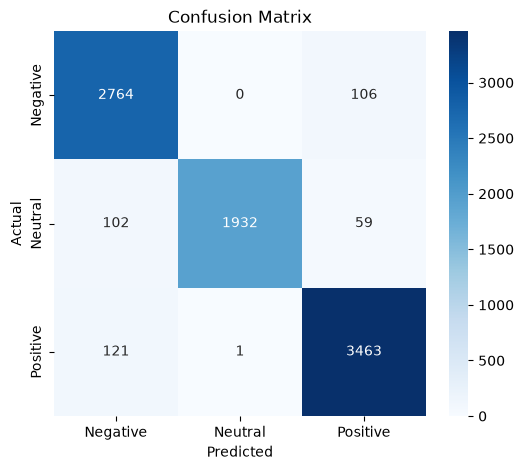

In [49]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(
    y_test,
    y_pred
)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=encoder.classes_,
    yticklabels=encoder.classes_
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()

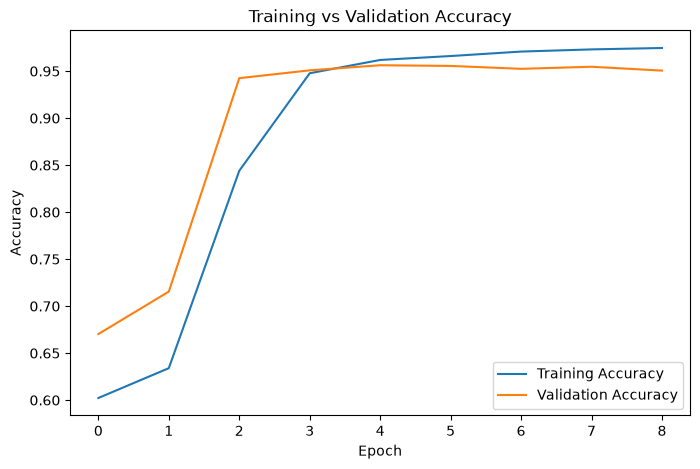

In [50]:
plt.figure(figsize=(8,5))

plt.plot(
    history.history["accuracy"],
    label="Training Accuracy"
)

plt.plot(
    history.history["val_accuracy"],
    label="Validation Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy")
plt.legend()

plt.show()

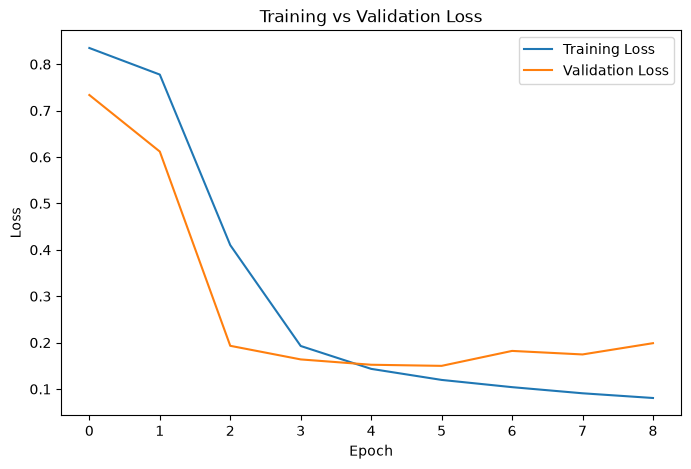

In [51]:
plt.figure(figsize=(8,5))

plt.plot(
    history.history["loss"],
    label="Training Loss"
)

plt.plot(
    history.history["val_loss"],
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()

plt.show()

In [59]:
model.save("../models/lstm_model.keras")

In [60]:
import pickle

with open("../models/tokenizer.pkl", "wb") as file:
    pickle.dump(tokenizer, file)

In [58]:
review = ["battery is not good"]

sequence = tokenizer.texts_to_sequences(review)

padded = pad_sequences(
    sequence,
    maxlen=MAX_LENGTH,
    padding="post"
)

prediction = model.predict(padded)

predicted_class = np.argmax(prediction)

print("Predicted Sentiment:", encoder.inverse_transform([predicted_class])[0])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step
Predicted Sentiment: Negative


In [65]:
df.Sentiment_Label.value_counts()

Sentiment_Label
2    17923
0    14348
1    10468
Name: count, dtype: int64

In [69]:
from sklearn.metrics import precision_score, recall_score, f1_score

f1_score(y_test, y_pred, average = "weighted")

0.9546001943423575

In [71]:
y_test[:10].to_numpy()

array([2, 2, 2, 0, 2, 1, 1, 1, 0, 2])

In [72]:
y_pred[:10]

array([2, 2, 2, 0, 2, 1, 1, 1, 0, 2])